# CSCI 345: Machine Learning
## Topic: Classification Models

**Name:** Jaxon Schroeder  
**Date:** 9/01/2026 
**Estimated time:** 75–90 minutes

This notebook introduces two fundamental classification algorithms:
- Logistic Regression and K-Nearest Neighbors (KNN).

We will explore how these models can be used to classify observations,
prepare data for classification, make predictions, and evaluate model performance.


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Logistic Regression


Not all problems are continuous


- There are instances where we want to determine a binary state


- Logistic regression is good for qualitative results


- Logistic regression is concerned with the probability that a response falls into a particular category


## Evaluating Classification

- True Positives
- True Negatives
- False Positives
- False Negatives


Logistic regression uses a Sigmoid function for situations where outputs can have one of two values either 0 or 1


$$\omega(z)=\frac{1}{1+e^{-z}}$$


In [ ]:
def sigmoid(x):
    return (1/(1+np.exp(-x)))

x = np.linspace(-6,6,100)
plt.plot(x,sigmoid(x))

**Take our linear regression solution and put it into a logistic model**

$$\omega(z)=\frac{1}{1+e^{-(x\beta + \epsilon)}}$$


## Example: Sinking of the Titanic

The Challenge:

The sinking of the Titanic is one of the most infamous shipwrecks in history.


On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.


While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.


In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).


In [2]:
# Use pandas to read in csv file
train = pd.read_csv('titanic.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Locates and Visualizes the Missing Values

- You cannot train a machine learning model with missing values. It will not know what to do.


In [4]:
# Use the .isnull() method to locate missing data
missing_values = train.isnull()
missing_values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

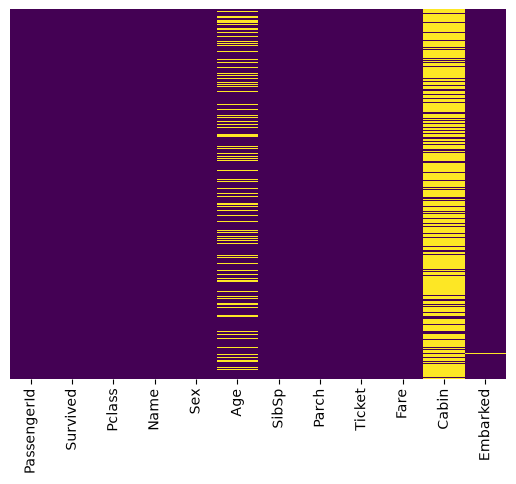

In [5]:
# Use seaborn to conduct heatmap to identify missing data
# data -> argument refers to the data to create heatmap
# yticklabels -> argument avoids plotting the column names
# cbar -> argument identifies if a colorbar is required or not
# cmap -> argument identifies the color of the heatmap
sns.heatmap(data = missing_values, yticklabels=False, cbar=False, cmap='viridis')

### Step 1: Viewing the ratios of the labels


<Axes: xlabel='Survived', ylabel='count'>

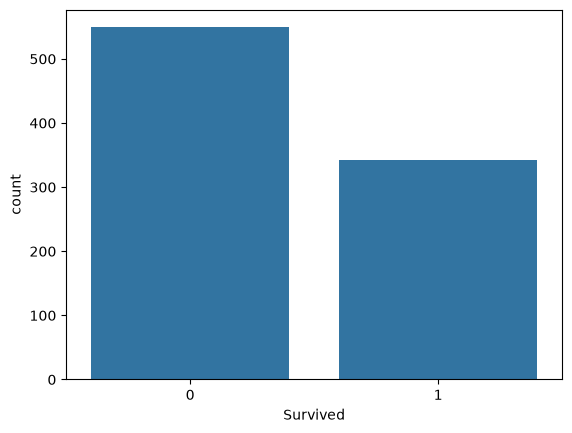

In [6]:
# Use the countplot() method to identify ratio of who survived vs. not
# (Tip) very helpful to get a visualization of the target label
# x -> argument refers to column of interest
# data -> argument refers to dataset
sns.countplot(x='Survived', data=train)

#### Survival Based on Category


<Axes: xlabel='Survived', ylabel='count'>

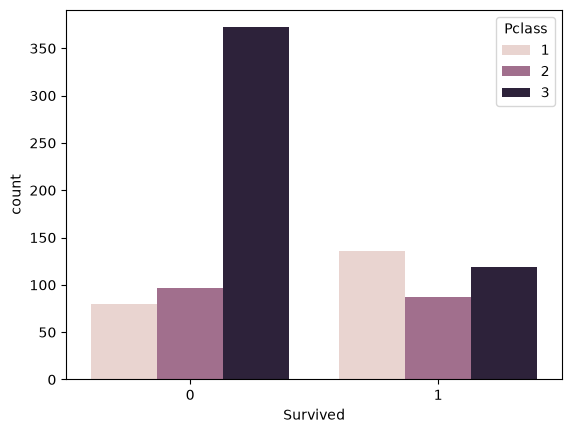

In [7]:
# Use the countplot() method to identify ratio of who survived vs. not with interest in Passenger class
# x -> argument refers to column of interest
# data -> argument refers to dataset
# hue -> allows another level to subdivide data
# palette -> argument refers to plot color
sns.countplot(x='Survived', data=train, hue='Pclass')

**What to do with all this missing data?**


We can impute or infill these values based on the data distribution

- When doing this it is important to look at the data distribution to make sure this makes sense


<Axes: xlabel='Pclass', ylabel='Age'>

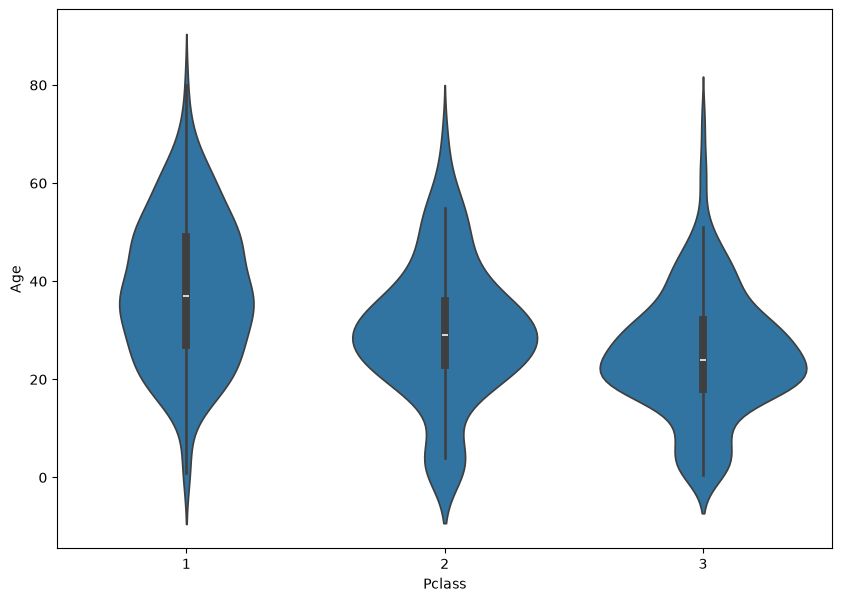

In [8]:
plt.figure(figsize=(10,7))
sns.violinplot(x='Pclass', y='Age', data = train)

### Step 2: Create a function to Impute Missing Values


In [11]:
# Create function to impute the age value if it is null
def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]
    
    if pd.isnull(Age):
        
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age
    
    
# Apply function to impute the age for missing values
# The age column is at position 0
# The pclass column is at position 1
# axis -> argument refers to columns instead of rows to apply the impute_age function
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

In [13]:
# Create function to replace the few empty Embark Values
def impute_embark(cols, value):
    embark = cols.iloc[0]
    
    if pd.isnull(embark):
        return value
    else: 
        return embark

    
train['Embarked'] = train[['Embarked']].apply(impute_embark, axis=1, args = (train['Embarked'].mode()[0]))

### Step 3: Visualize Imputed Results


**It is always important when you modify data you check that it worked**


<Axes: >

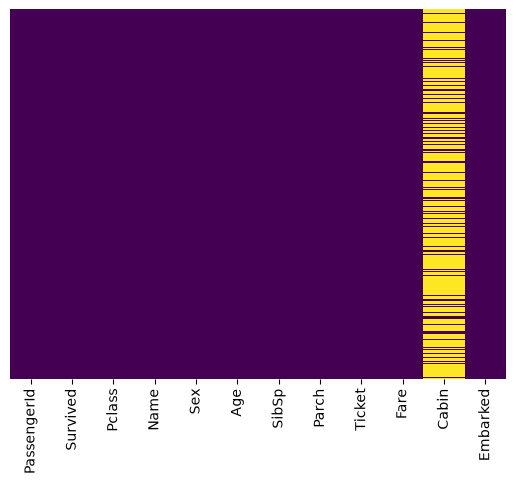

In [14]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

**There are barely any cabin entries we should ignore them**


In [15]:
# use .dropna() method to remove rows that contain missing values
train.dropna(inplace=True)

### Step 4: Encoding Categorical Variables

**What should we do with categorical variables?**


We need to convert categorical variables (not understood by computers) into dummy variables that can be understood.


- Produces what is known as a one-hot encoded vector


![](./figs/one_hot_encoded.png)


In [17]:
# Use the .get_dummies() method to convert categorical data into dummy values
# train['Sex'] refers to the column we want to convert
# drop_first -> argument avoids the multicollinearity problem, which can undermines
# the statistical significance of an independent variable.
sex = pd.get_dummies(train['Sex'], drop_first=True) # drop first means k-1 values
embark = pd.get_dummies(train['Embarked'], drop_first=True)

# Use  .concat() method to merge the series data into one dataframe
train = pd.concat([train, sex, embark], axis=1)

### Step 5: Data Filtering

Remove any insignificant features from the dataset


In [18]:
# Drop columns with categorical data
train.drop(['Sex','Embarked','Ticket','Name','PassengerId'], axis=1, inplace=True)

### Step 6: Split the data into features and labels


In [19]:
# Split data into 'X' features and 'y' target label sets
X = train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q',
       'S']]
y = train['Survived']

### Step 7: Test/Train Split


In [20]:
# Split data set into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

### Step 8: Create and Train the Model


In [30]:
# Create instance (i.e. object) of LogisticRegression
X_train_clean = X_train.loc[:,~X_train.columns.duplicated()]
logmodel = LogisticRegression(max_iter=1000)

# Fit the model using the training data
# X_train -> parameter supplies the data features
# y_train -> parameter supplies the target labels
logmodel.fit(X_train_clean, y_train)

[False False False False False False False False]


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [31]:
from sklearn.neighbors import KNeighborsClassifier

# Create instance (i.e. object) of KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_clean, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [34]:
from sklearn.metrics import classification_report
X_test_clean = X_test.loc[:,~X_test.columns.duplicated()]
predictions = logmodel.predict(X_test_clean)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.54      0.58        26
           1       0.70      0.78      0.74        36

    accuracy                           0.68        62
   macro avg       0.67      0.66      0.66        62
weighted avg       0.67      0.68      0.67        62



In [41]:
# Use the .predict() method to make predictions on the test data for the KNN model
knn_predictions = knn.predict(X_test_clean)
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       0.57      0.15      0.24        26
           1       0.60      0.92      0.73        36

    accuracy                           0.60        62
   macro avg       0.59      0.54      0.48        62
weighted avg       0.59      0.60      0.52        62



### Step 9: Score the Model

#### F1-Score

It is calculated from the precision and recall of the test

- **Precision** is the number of true positive results divided by the number of all positive results, including those not identified correctly
  - known as positive predictive value

$$ Precision = \frac{True\,Positives}{True\,Positives + False\,Positives} $$

    - within everything that is predicted positive this is the percentage correct


- **Recall** is the number of true positive results divided by the number of all samples that should have been identified as positive.
  - known as sensitivity in diagnostic binary classification

$$ Recall = \frac{True\,Positives}{True\,Positives + False\,Negatives} $$

    - what is the fraction of actual positive results the model found


$$
F_1 = \frac{2}{\mathrm{recall}^{-1} + \mathrm{precision}^{-1}} = 2 \frac{\mathrm{precision} \cdot \mathrm{recall}}{\mathrm{precision} + \mathrm{recall}} = \frac{2\mathrm{tp}}{2\mathrm{tp} + \mathrm{fp} + \mathrm{fn}}
$$


### Step 10: Visualizing Results


In [39]:
# computes the confusion matrix
cm = confusion_matrix(y_test, predictions)

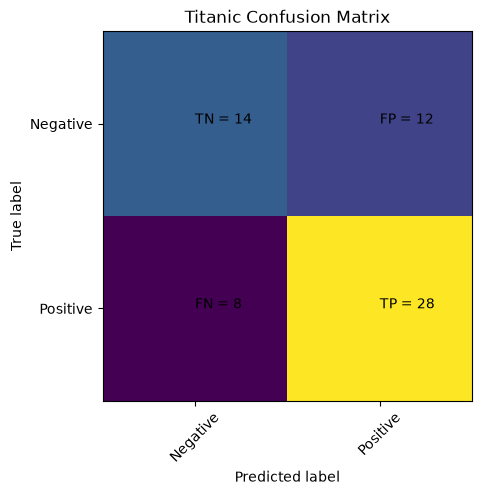

In [40]:
# Plots the confusion matrix

plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Titanic Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

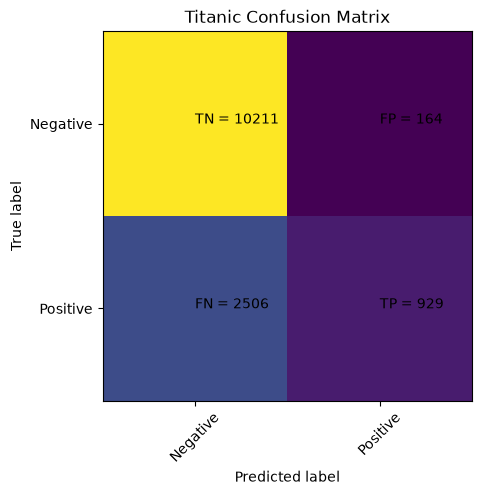

In [91]:
#Visualize the confusion matrix for the KNN model
knn_cm = confusion_matrix(y_test, knn_predictions)

plt.clf()
plt.imshow(knn_cm, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Titanic Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(knn_cm[i][j]))
plt.show()

### Step 11. Analysis

Compare the performance of the two classification models and provide an analysis of their results.

When comparing the confusion matrix for the Titantic and Knn models, they had identical results , however when examining the predictions, the Knn model showed overall lower scores than the Titantic model, with the exception of recall in the 1 row having a higher score and identical scores in support.

### Task: Predict Titanic Survival

Load the **new Titanic test dataset (titanic_unseen.csv)**, which is separate from the data used to train and evaluate the models.

- Apply the same preprocessing used during training.
- Use the trained **Logistic Regression** and **KNN** models to predict passenger survival.
- Compare the predictions from both models and identify any differences.

> **Goal:** Use the trained models to predict survival on completely unseen Titanic data.


## Multiclass classification

If you have several classes to predict, an option often used is to fit one-versus-all classifiers and then use a voting heuristic for the final decision.


In [48]:
from sklearn.datasets import load_iris

# loads the dataset
X, y = load_iris(return_X_y=True)

# Instantiates the model and computes the logistic regression
clf = LogisticRegression(random_state=0, solver='lbfgs', max_iter=1000).fit(X, y)

# This predicts the classes
clf.predict(X[:2, :])

array([0, 0])

In [49]:
# predicting the probability
clf.predict_proba(X[:2, :]) 

array([[9.81660912e-01, 1.83390740e-02, 1.44175934e-08],
       [9.71515725e-01, 2.84842451e-02, 3.01369302e-08]])

In [50]:
# Shows the score for the model
clf.score(X, y)

0.9733333333333334

## Adult Data Set

The **Adult data set**, also known as the "Census Income" data set, is a another popular classification data set. Whereas Iris is particularly simple and often used only for learning, testing, and examples, the Adult data set is often used in ML research papers.

This data set is part of the [UCI machine learning repository](https://archive.ics.uci.edu/), which contains 664 different data sets that you can browse. [OpenML](https://www.openml.org/) is a platform that hosts many data sets, *including* many from the UCI ML repository. Scikit-learn provides functions for loading data sets from OpenML, which can be used to load the Adult data set. Note that you could also find and download the data set directly and load it from your machine locally. These loading functions don't require you to send the data set with your code, but do cause your programs to download them (at least once) when your code is run.

### Data Set Overview

The Adult data set is extracted from the 1994 Census database of the United States. It is commonly used for predicting whether an individual's income exceeds $50,000 per year based on census data. This task is framed as a binary classification problem.

### Features

The data set contains 14 attributes, including:

1. **Age**: The age of the individual.
2. **Workclass**: The type of employer the individual has (e.g., private, federal-gov).
3. **fnlwgt**: Final weight. The number of people the census believes the entry represents. E.g., a value of 50 means that the person's data represents 50 people in the real population with similar attributes. Individual people can be represented by multiple rows, so `fnlwgt` does not sum to the US population. This "binning" of people helps to preserve privacy.
4. **Education**: The highest level of education achieved by the individual.
5. **Education-Num**: The highest level of education in numerical form.
6. **Marital Status**: Marital status of the individual.
7. **Occupation**: The individual's occupation.
8. **Relationship**: The individual's role in the family.
9. **Race**: The race of the individual.
10. **Sex**: The gender of the individual.
11. **Capital Gain**: Income from investment sources, apart from wages/salary.
12. **Capital Loss**: Losses from investment sources, apart from wages/salary.
13. **Hours per Week**: Number of hours worked per week.
14. **Native Country**: Country of origin for the individual.

### Target Variable

- **Income**: Whether the individual earns more than $50,000 per year.


In [58]:
from sklearn.datasets import fetch_openml                                       # OpenML contains many useful data sets, including Adult.

adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')     # Fetch the Adult dataset. as_frame=True indicates that we're using pandas and makes adult.data a DataFrame (among other changes)
df = adult.data                                                                 # Pull off the DataFrame, as we will manipulate it to append the labels
df['income'] = adult.target                                                     # Add the target column (what we aim to predict)
display(df)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**Question**: Is each column numerical, categorical, text, or an image? Continuous, discrete, nominal, or ordinal?

A DataFrame object stores information about the type of each column in `DataFrame.dtype`:

In [52]:
# We can get the types of columns using .dtype. This is a type object, not a string.
print('Second column .dtype is:');
print('\tType: ', type(df['workclass'].dtype))
print('\tValue: ', df['workclass'].dtype)

# We can get the string representation of the type with dtype.name. This is useful when we want to compare the type to a string.
print('Second column .dtype.name is:');
print('\tType: ', type(df['workclass'].dtype.name))
print('\tValue: ', df['workclass'].dtype.name)

Second column .dtype is:
	Type:  <class 'pandas.CategoricalDtype'>
	Value:  category
Second column .dtype.name is:
	Type:  <class 'str'>
	Value:  category


For columns that are categorical, we can query the set of possible categories:

In [ ]:
df['workclass'].cat.categories # Returns a pandas Index of unique categories in the 'workclass' column.

Above, the '.cat' accessor is used for accessing categorical data specific methods and attributes. 

The table below describes common values of dtype in pandas:

| Pandas dtype    | Description / Usage                                           |
|-----------------|---------------------------------------------------------------|
| `object`        | Typically strings or mixed types.                             |
| `int64`         | Integer numbers.                                              |
| `float64`       | Floating point numbers.                                       |
| `bool`          | Boolean values (True or False).                               |
| `datetime64`    | Date and time values.                                         |
| `category`      | Finite list of text values. Useful for categorical variables. |


Let's use these tools to get the type and values of each possible feature:

In [ ]:
# Notice that df.columns is an attribute of a DataFrame of type pandas Index, which stores the column names.
print("df.columns:");
display(df.columns)

print("\nHere are the possible values for all categorical columns:")
# Iterate through each column and print the feature name and unique values or type. 
for column in df.columns:                                               # Note that pandas.Index is "iterable" in this way.
    # Check if the column is of object type (categorical)
    if df[column].dtype.name == 'category':
        # Print the feature name and its unique values
        print(f"\033[1m{column}:\033[0m {df[column].cat.categories}")   # \033[1m sets to bold, and \033[0m back to normal text.
    else:
        # Print the feature name and its type
        print(f"\033[1m{column} (numerical):\033[0m {df[column].dtype}")

### Task: Build Classification Models

Using the **Adult Data Set**, build and evaluate classification models to predict whether an individual's annual income is **greater than $50,000**.

1. **Prepare the data** by identifying the features and target variable, handling missing values, and converting categorical variables into a suitable numerical format.

2. **Split the data** into training and testing sets.

3. **Standardize the appropriate numerical features**, particularly for K-Nearest Neighbors.

4. Build a **Logistic Regression** model to predict the `Income` target.

5. Build a **K-Nearest Neighbors (KNN)** model and select an appropriate value of \(k\).

6. Use both models to **make predictions** on the test data.

7. **Evaluate and compare** the models using appropriate classification metrics, such as accuracy, precision, recall, F1-score, and a confusion matrix.

8. **Analyze the results** and discuss which model performs better and why.

> **Goal:** Use the individual's census characteristics to predict whether their income exceeds **$50,000 per year**, and compare the performance of Logistic Regression and KNN on this classification task.


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier                                    # OpenML contains many useful data sets, including Adult.
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report

# Features to pull:workclass, education, occupation, capital-gain, capital-loss, income
adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')     # Fetch the Adult dataset. as_frame=True indicates that we're using pandas and makes adult.data a DataFrame (among other changes)
df = adult.data                                                                 # Pull off the DataFrame, as we will manipulate it to append the labels
df.drop(columns=['fnlwgt', 'marital-status', 'relationship', 'race', 'sex', 'native-country'], inplace=True)    

Edu_lvl = pd.get_dummies(df['education'], drop_first=True) # drop first means k-1 values
Edu_lvl.drop(columns=['Preschool', 'Some-college', "1st-4th", "5th-6th", "7th-8th", "9th", "11th", "12th"],  inplace=True) # drop the first column to avoid multicollinearity

workclass = pd.get_dummies(df['workclass'], drop_first=True) # drop first means k-1 values
workclass.drop(columns=['Never-worked', "Without-pay"], inplace=True) # drop the first column to avoid multicollinearity
df.drop(columns=['education', 'workclass'], inplace=True) # drop the original column
# Use  .concat() method to merge the series data into one dataframe
df = pd.concat([df, Edu_lvl, workclass], axis=1)

#sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
df.dropna(inplace=True)
df['income'] = adult.target 
# Split data into 'X' features and 'y' target label sets
X = df[['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'Doctorate', 'HS-grad', 'Masters', 'Prof-school', 'Bachelors', 'Assoc-acdm', 'Assoc-voc', 'Doctorate']]
y = df['income']
# Split data set into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
# Create instance (i.e. object) of LogisticRegression
X_train_clean = X_train.loc[:,~X_train.columns.duplicated()]
logmodel = LogisticRegression(max_iter=10000)

# Fit the model using the training data
# X_train -> parameter supplies the data features
# y_train -> parameter supplies the target labels
logmodel.fit(X_train_clean, y_train)

# Create instance (i.e. object) of KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=500)
knn.fit(X_train_clean, y_train)

X_test_clean = X_test.loc[:,~X_test.columns.duplicated()]
predictions = logmodel.predict(X_test_clean)
prediction_acc_log = accuracy_score(y_test, predictions)
print("Logistic Regression Accuracy:", prediction_acc_log)
print(classification_report(y_test, predictions))

# Plots the confusion matrix (for the logistic regression model)
cmlog = confusion_matrix(y_test, predictions)
plt.clf()
plt.imshow(cmlog, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Income Confusion Matrix (Logistic Regression)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cmlog[i][j]))
plt.show()

knn_predictions = knn.predict(X_test_clean)
prediction_acc_knn = accuracy_score(y_test, knn_predictions)
print("KNN Accuracy:", prediction_acc_knn)
print(classification_report(y_test, knn_predictions))



# Plots the confusion matrix (for the logistic regression model)
cmknn = confusion_matrix(y_test, knn_predictions)
plt.clf()
plt.imshow(cmknn, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Income Confusion Matrix (Logistic Regression)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cmknn[i][j]))
plt.show()

Based on the results, I would say that the knn model is slighty better at predicting overall compared to the logistic model with increased accuracy by a 2% difference and stronger overall percision. However the Logistic model showed stronger recall and f1-score scores in comparison. While the two models are comparable, the Knn model shows more potential for being an accurate model.